In [6]:
import os
from collections import namedtuple
from itertools import batched, chain
import json
import math
from multiprocessing import Pool
from pathlib import Path

from datasets import load_from_disk
import matplotlib.pyplot as plt
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import sys
import os
# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.detectors.impostor import ImpostorDetector

In [7]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica, sans-serif'
plt.rcParams['font.size'] = 6.5
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['grid.linewidth'] = .25

In [ ]:
from concurrent.futures import ThreadPoolExecutor
import re
from sklearn.metrics import roc_curve, precision_recall_curve, accuracy_score, f1_score

bytepair_tokenizer = AutoTokenizer.from_pretrained('gpt2', truncation=False, max_length=None, model_max_length=None)


def tokenize_bytepair(text):
    return bytepair_tokenizer.tokenize(text)


def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())


def normalize_pair(text_pair):
    return tuple(normalize_text(t) for t in text_pair)


def impostor(text_pairs, **imposter_kwargs):
    # text_pairs is list of pairs, but get_scores expects list of texts and batches them
    pairs = text_pairs['pair']  # Assuming this is a list of (text1, text2) tuples

    def compute_score(pair):
        impostor_det = ImpostorDetector(**imposter_kwargs)
        # norm_pair = tuple(normalize_text(t) for t in pair)
        # Koppel et Al. (2014) do not normalize text pairs
        norm_pair = pair
        return impostor_det.get_scores(norm_pair)

    with ThreadPoolExecutor() as executor:
        scores = list(executor.map(compute_score, pairs))
    # TODO: compare scores with the expected output 
    return scores


def plot_decision_threshold_imposter(scores, labels, savefig_basepath:str=None, title_kwargs:dict=None):
    # scores = normalize_scores(scores) # doesn't not help

    # ROC Curve: Balanced classes or when you care about TPR vs. FPR
    # displayed for different thresholds
    # scores: probability estimates of the positive class, confidence values, or non-thresholded measure of decisions (as returned by “decision_function” on some classifiers)
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html (05.06.2025)
    fpr, tpr, roc_thresholds = roc_curve(labels, scores)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label='ROC Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "ROC Curve" if not title_kwargs else f"ROC Curve\n{title_kwargs}"
    plt.title(title)
    plt.legend()

    # Precision-Recall Curve: 	Imbalanced 
    # scores: non-thresholded measure of decisions, relative ranking of predictions
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html (05.06.2025)
    precision, recall, pr_thresholds = precision_recall_curve(labels, scores)
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label='PR Curve', color='orange')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    title = "Precision-Recall Curve" if not title_kwargs else f"Precision-Recall Curve\n{title_kwargs}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if savefig_basepath:
        figure_name = "roc_prec_recall_curve.png" if not title_kwargs else f"roc_prec_recall_curve_r{title_kwargs['rounds']}_top{title_kwargs['top_n']}.png"
        savefig = os.path.join(savefig_basepath, figure_name)
        plt.savefig(savefig)
    plt.show()

    # Threshold vs F1 score
    thresholds = np.linspace(min(scores), max(scores), 100)
    f1_scores = [f1_score(labels, scores >= t) for t in thresholds]

    plt.figure()
    plt.plot(thresholds, f1_scores)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    title = "Threshold vs F1 Score" if not title_kwargs else f"Threshold vs F1 Score\n{title_kwargs}"
    plt.title(title)
    plt.grid(True)
    if savefig_basepath:
        figure_name = "f1_thres_curve.png" if not title_kwargs else f"f1_thres_curve_r{title_kwargs['rounds']}_top{title_kwargs['top_n']}.png"
        savefig = os.path.join(savefig_basepath, figure_name)
        plt.savefig(savefig)
    plt.show()


# PAN 23

In [9]:
# PAN 23
ds_pan23 = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN23))['train'].to_pandas()[:500]
labels = ds_pan23['same'][:500]
display(ds_pan23.head())

,id,discourse_types,pair,same,authors
0,a0e656a3-955e-44f6-b5b3-dfd6e360a962,"[email, speech_transcription]",[I think I have decided with regards to the <t...,True,"[en_7, en_7]"
1,c42efa75-f418-4fac-80ca-4d0982704d25,"[email, speech_transcription]","[Dear <addr10_NN>, <nl><nl>If I was to go with...",True,"[en_31, en_31]"
2,a3a6745f-af62-4889-af49-93ec88594142,"[interview, email]","[So, erm, so I’m, erm, I’m actually from <cou...",True,"[en_88, en_88]"
3,244235f3-4647-4ed3-b078-60a2ea2850b7,"[email, speech_transcription]","[Hi <addr2_FN><nl><nl>This is my picture, that...",False,"[en_27, en_38]"
4,d410b3f0-b331-48ab-a524-c29ed1d487a2,"[interview, email]","[Oh, okay. Erm, well, I think of myself as kin...",False,"[en_87, en_32]"


In [10]:
# one elmenent = averaged score of X,Y and Y,X pair (score=number of rounds where the candidate was the most similar)
args = {
    'top_n': 100000,
    'portion_delete': 0.5,
    'rounds': 100,
    'shared_vocab_only': True
}
scores_pan23_top_n = impostor(ds_pan23, **args)

In [11]:
len(labels), len(scores_pan23_top_n),len([])

(500, 500, 0)

In [12]:
labels = [l for i,l in enumerate(labels) if len(scores_pan23_top_n[i]) > 0]
scores_pan23_top_n = [s for s in scores_pan23_top_n if len(s) > 0]

In [13]:
scores_pan23_top_n 

[[53.0],
 [20.5],
 [4.0],
 [53.5],
 [0.0],
 [62.0],
 [0.0],
 [2.0],
 [69.5],
 [44.5],
 [8.5],
 [36.5],
 [1.0],
 [6.0],
 [43.0],
 [80.5],
 [92.0],
 [47.0],
 [4.0],
 [14.5],
 [39.5],
 [46.0],
 [17.0],
 [7.0],
 [69.5],
 [0.5],
 [66.5],
 [2.0],
 [5.0],
 [5.5],
 [82.5],
 [10.0],
 [88.5],
 [46.5],
 [0.0],
 [1.0],
 [8.0],
 [36.5],
 [47.0],
 [4.5],
 [2.5],
 [6.5],
 [20.0],
 [24.5],
 [33.5],
 [34.0],
 [86.0],
 [15.5],
 [13.5],
 [0.0],
 [22.5],
 [35.0],
 [87.5],
 [28.5],
 [58.0],
 [49.5],
 [44.0],
 [28.0],
 [25.5],
 [9.5],
 [46.5],
 [38.0],
 [29.0],
 [52.0],
 [39.0],
 [41.5],
 [60.0],
 [54.0],
 [17.0],
 [6.5],
 [38.0],
 [2.5],
 [91.5],
 [27.0],
 [31.5],
 [4.0],
 [8.0],
 [1.5],
 [5.5],
 [11.5],
 [1.0],
 [16.0],
 [6.0],
 [8.5],
 [0.0],
 [42.5],
 [39.0],
 [75.5],
 [14.5],
 [54.5],
 [14.0],
 [5.0],
 [71.0],
 [0.0],
 [95.5],
 [96.0],
 [91.5],
 [98.0],
 [15.5],
 [55.0],
 [82.5],
 [4.0],
 [9.0],
 [65.0],
 [19.0],
 [41.0],
 [90.5],
 [77.0],
 [27.0],
 [7.5],
 [2.0],
 [15.0],
 [31.5],
 [27.0],
 [58.0],
 [

In [14]:
sys.path.append(os.path.abspath(".."))
save_path = Path.cwd().parent / CONFIG.SAVE_PATH / 'impostor_scores' / CONFIG.PAN23
save_path.mkdir(parents=True, exist_ok=True)

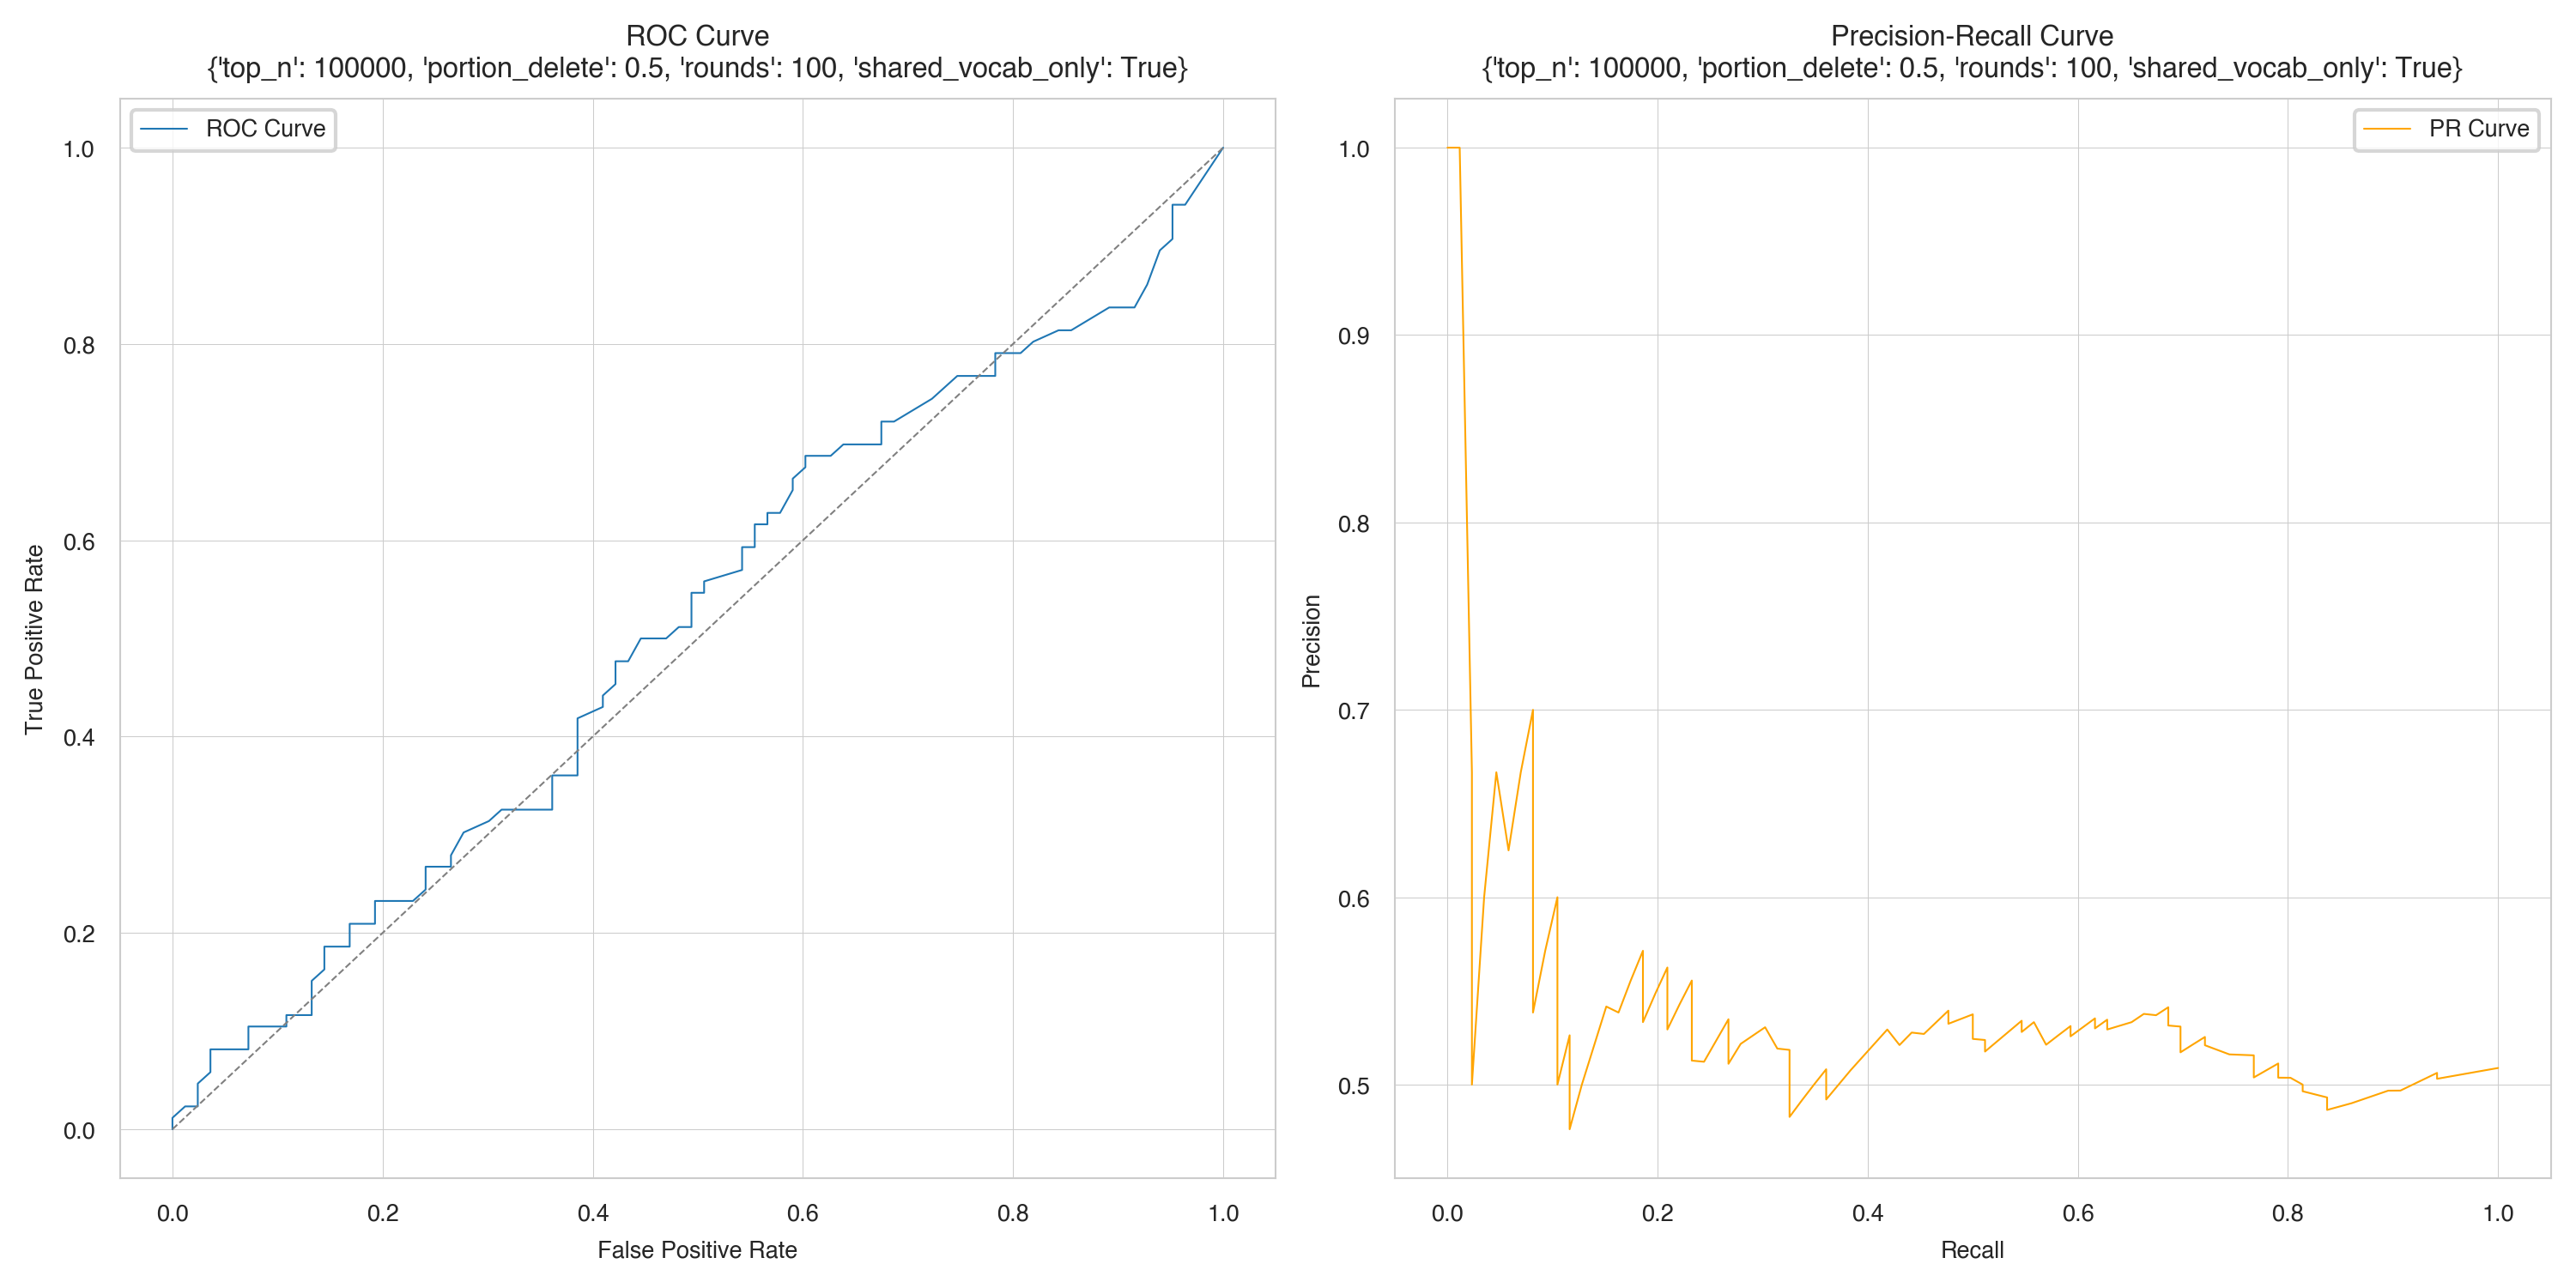

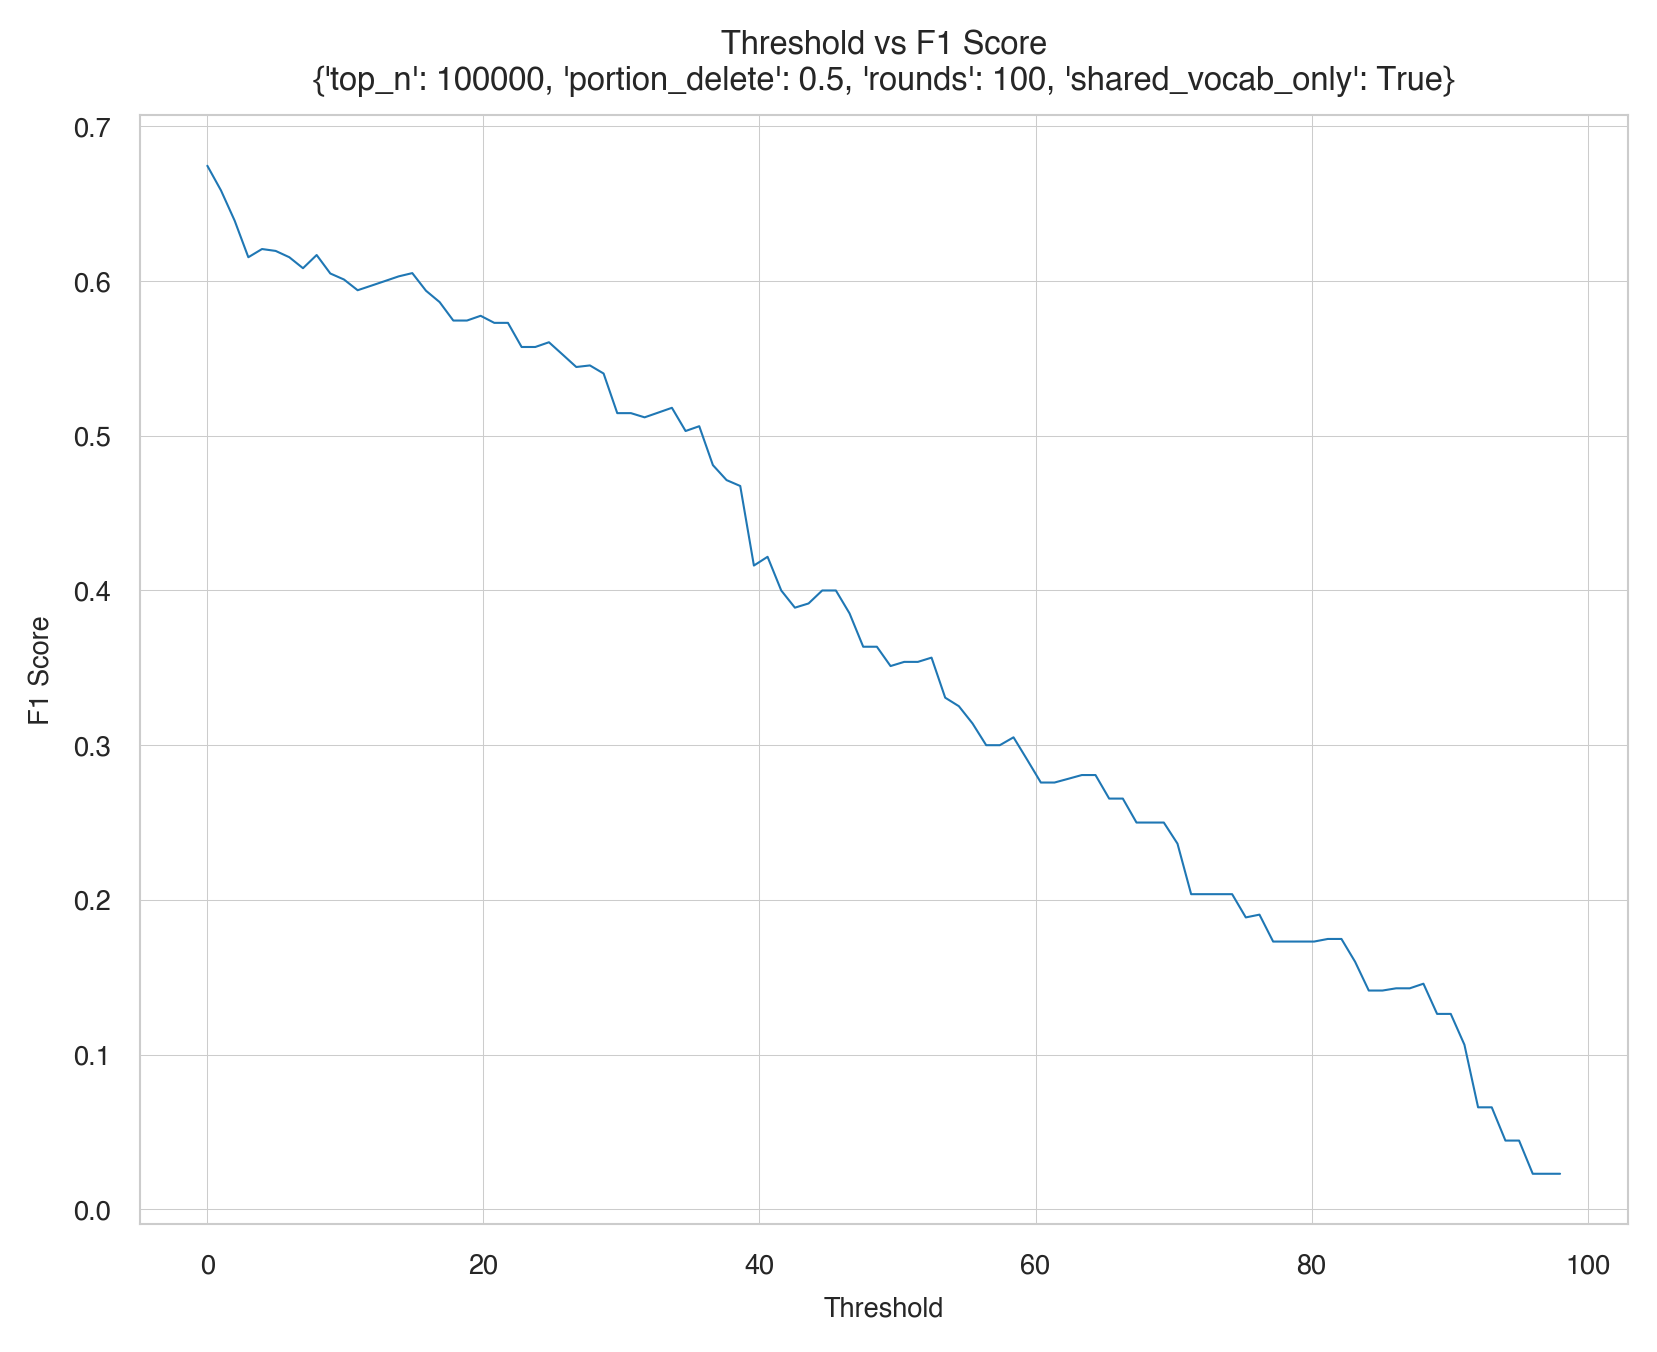

In [15]:
plot_decision_threshold_imposter(scores_pan23_top_n, labels=labels, title_kwargs=args, savefig_basepath=save_path)

# PAN 20

Contains way more elements than PAN23, and thus, kernel locally is killed when using complete dataset.

In [16]:
# PAN 20
ds_pan20 = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN20))['train'].to_pandas()
# 4418 is number of positive and negative samples in PAN 23
df_true = ds_pan20[ds_pan20['same'] == True].sample(n=4418, random_state=42)
df_false = ds_pan20[ds_pan20['same'] == False].sample(n=4418, random_state=42)

# Combine and shuffle the result
ds_pan20 = pd.concat([df_true, df_false]).sample(frac=1, random_state=42).reset_index(drop=True)

labels = ds_pan20['same']
display(ds_pan20.head())

,id,fandoms,pair,same,authors
0,2428e0a1-4204-5976-9c85-cd723b0d0963,"[Hetalia - Axis Powers, Van Helsing]",[The plot bunny attacked and I must be its ser...,True,"[812168, 812168]"
1,174fad06-4435-54ae-a3d3-89932e2663a6,"[Home Improvement, Suite Life series]",[Jill closed the door and picked up her laundr...,False,"[6766916, 853237]"
2,3012216b-fddf-53e9-aa0e-f57dc591f33e,"[Love Hina, Sonic the Hedgehog]",[Keitaro shrugged. The last thing he wanted wa...,True,"[190737, 190737]"
3,e26920ca-15c2-5ad1-b88a-2bc3865d1fda,"[Merlin, Voltron: Legendary Defender]",[Malcolm stopped abruptly before a closed door...,True,"[6836632, 6836632]"
4,5afe9434-f7ec-5e3b-8925-5c05271b635f,"[Attack on Titan/進撃の巨人, Fantastic Beasts and W...",[Levi watches Petra for a moment his brows sli...,True,"[1736516, 1736516]"


In [17]:
# scores_pan20_top_n = impostor(ds_pan20, **args)

In [18]:
sys.path.append(os.path.abspath(".."))
save_path = Path.cwd().parent / CONFIG.SAVE_PATH / 'impostor_scores' / CONFIG.PAN20
save_path.mkdir(parents=True, exist_ok=True)

In [19]:
# plot_decision_threshold_imposter(scores_pan20_top_n, labels=labels, title_kwargs=args, savefig_basepath=save_path)

# PAN 25

In [20]:

# def sample_texts(h, m, min_text_ln=500, n_texts=30, seed=42):
#     """
#     Sample texts from the human and machine datasets, ensuring that each text has at least `min_text_ln` characters.
#     Sampling disregards the author frequency, so that each text is sampled independently.
#     """
#     h = h.query('text.str.len() >= @min_text_ln')
#     h = h.sample(n=min(h['id'].count(), n_texts), random_state=seed)

#     m = {k: v.query('text.str.len() >= @min_text_ln') for k, v in m.items()}
#     m = {k: v.sample(n=min(n_texts, v['id'].count()), random_state=seed) for k, v in m.items()}

#     return h, m

# def _label_score_pairings(scores, pairing_label):
#     # value in brackets is pair ID, rounds are summed up and averaged for X,Y and Y,X in one number each
#     # print('scores',scores, len(scores))
#     # scores = pd.DataFrame({f'{pairing_label} ({i:04})': [c] for i, c in enumerate(scores)})
#     # scores['pairing'] = pairing_label
#     # return scores

#     return pd.DataFrame({
#             'doc_pair_id': [f'{i:04}' for i in range(len(scores))],
#             pairing_label: scores
#         }).set_index('doc_pair_id')

# def reformat_pairing_df(df):
#     """
#     Converts a long-format _label_score_pairings() output DataFrame
#     into a standardized format with 'doc_id' as index and pairing label as column.
#     """
#     # Extract column name that contains the scores (ignoring the 'pairing' column)
#     score_col = next(c for c in df.columns if c != 'pairing')
    
#     # Extract the pairing label and doc_id from the column name
#     match = re.match(r'(.+?) \((\d{4})\)', score_col)
#     if not match:
#         raise ValueError(f"Invalid column name format: {score_col}")
    
#     pairing_label, doc_id = match.groups()
    
#     # Build a new DataFrame with doc_id as index and pairing label as column
#     return pd.DataFrame({pairing_label: df[score_col].values}, index=[doc_id])


# def old_impostor(texts_h, texts_m, **imposter_kwargs):
#     impostor_det = ImpostorDetector(strict=True, **imposter_kwargs)
#     # TODO
#     with Pool() as pool:
#         th = texts_h['text'].map(normalize_text)
#         th = th.iloc[:len(th) // 2 * 2]     # Ensure rows are a multiple of two
#         l = 'Human / Human'
#         scores_h = tqdm(pool.imap(impostor_det.get_scores, batched(th, n=2)), desc=f'Imposter {l}', total=len(th) // 2)
#         scores_h = _label_score_pairings(np.squeeze(list(scores_h), axis=1), 'Human / Human')

#         scores_m = []
#         scores_hm = []
#         machine_names = list(texts_m.keys())
#         for i, tm in enumerate(texts_m.values()):
#             tm = tm['text'].map(normalize_text).iloc[:len(tm) // 2 * 2]
#             l = f'{machine_names[i]} / {machine_names[i]}'
#             cm = list(tqdm(pool.imap(impostor_det.get_scores, batched(tm, n=2)), desc=f'Imposter {l}', total=len(tm) // 2))
#             scores_m.append(_label_score_pairings(np.squeeze(list(cm), axis=1), l))

#             n = min(len(th), len(tm)) // 2
#             l = f'Human / {machine_names[i]}'
#             it = zip(th[:n], tm[:n])
#             chm = list(tqdm(pool.imap(impostor_det.get_scores, it), desc=f'Imposter {l}', total=n))
#             scores_hm.append(_label_score_pairings(np.squeeze(list(chm), axis=1), l))

#         # # FIXME: how are score concatenated?
#         print('scores_h', scores_h, len(scores_h))
#         print('scores_m', scores_m, len(scores_m))
#         print('scores_hm', scores_hm, len(scores_hm))
#         # Convert and concatenate
#         curves = pd.concat([scores_h] + scores_m + scores_hm, axis=1).sort_index()

#     return curves

In [21]:
# TTestResult = namedtuple('TTestResult', ['t', 'dof', 'p', 'd'])


# def t_test(a, b):
#     t, p = stats.ttest_ind(a, b)
#     d = t * np.sqrt((len(a) + len(b)) / (len(a) * len(b)))
#     return TTestResult(t=t, dof=len(a) + len(b) - 2, p=p, d=d)


# def t_test_str(t: TTestResult, correction_factor=1):
#     p_str = f'< {.001:>5}' if t.p < .001 else f'= {t.p:>5,.3f}'
#     if correction_factor:
#         p_corr = t.p * correction_factor
#         if p_corr >= 1.:
#             p_str += ', p[bf] = 1.00'
#         else:
#             p_str += ', p[bf] ' + (f'< {.001:>5}' if p_corr < .001 else f'= {p_corr:>5,.3f}')
#     return f't({t.dof:,}) = {t.t:>6,.2f}, p {p_str.replace('0.', '.')}, d = {t.d:>4,.1f}'


# def print_t_test_for_curves(curves, min_round=10):
#     pairings = [p for p in curves['pairing'].unique() if not p.startswith('Human /')]
#     print('Differences from Human / Human:')
#     for pairing in pairings:
#         t = t_test(curves.query('round >= @min_round and pairing == "Human / Human"')['accuracy'].dropna(),
#                    curves.query('round >= @min_round and pairing == @pairing')['accuracy'].dropna())
#         print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')


# def print_t_test_for_compression(cbc):
#     pairings = [p for p in cbc['pairing'].unique() if not p.startswith('Human /')]
#     print('Differences from Human / Human:')
#     for pairing in pairings:
#         t = t_test(cbc.query('pairing == "Human / Human"')['score'],
#                    cbc.query('pairing == @pairing')['score'])
#         print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')

In [22]:
# def plot_old_impostor_curves(curves, savefig=None):
#     """
#     Plot the impostor curves from the given DataFrame.
#     Curves are sorted by value and values of the same document ID do not correspond to the same document pair, hence the x-axis has no meaning.
#     """
#     plt.figure(figsize=(12, 6))
#     for col in curves.columns:
#         plt.plot(curves.index, sorted(curves[col], reverse=True), label=col)    # id does not corresponf to value, bc sorted
#     plt.tick_params(
#         axis='x',          # changes apply to the x-axis
#         which='both',      # both major and minor ticks are affected
#         bottom=False,      # ticks along the bottom edge are off
#         top=False,         # ticks along the top edge are off
#         labelbottom=False) # labels along the bottom edge are off

#     plt.title('Impostor Score Over Document Pairs (High == Same Author)\nscores are sorted by value')
#     plt.ylabel('Score')

#     plt.legend(title='Pairing', bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()

#     if savefig:
#         plt.savefig(savefig)
#     plt.show()

In [23]:
# def split_pan_ds_dataset_by_model(df, seed=42):
#     df_human = df.query('model == "human"').sample(frac=1, random_state=seed)
#     df_machine = {
#         'gpt-4-turbo-paraphrase': df.query('model == "gpt-4-turbo-paraphrase"').sample(frac=1, random_state=seed),
#         'gemini-pro': df.query('model == "gemini-pro"').sample(frac=1, random_state=seed),
#         'gpt-4-turbo': df.query('model == "gpt-4-turbo"').sample(frac=1, random_state=seed),
#         'gemini-pro-paraphrase': df.query('model == "gemini-pro-paraphrase"').sample(frac=1, random_state=seed),
#     }
#     return df_human, df_machine 

# ds_pan = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN25))['train'].to_pandas()
# # label is string 'human' for human texts, but we want to have it as 0
# ds_pan['label'] = ds_pan['label'].map({'human': 0, 'machine': 1})
# print('Unique Models:', list(ds_pan['model'].unique()))
# df_pan_h, df_pan_m = split_pan_ds_dataset_by_model(ds_pan)


# display(df_pan_h.head())

# assert df_pan_h['label'].count() > 0 , "No human texts found in PAN dataset"
# assert df_pan_h['label'].sum() == 0, "PAN dataset contains human texts with labelled as AI-generated"

# sample_pan = sample_texts(df_pan_h, df_pan_m, n_texts=400)